In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load in desired dates of data and merge into one DataFrame

file_dates = [
    "202505", "202506", "202507", "202508", "202509",
    "202510", "202511", "202512",
    "202601", "202602", "202603", "202604", "202605",
]

df = pd.DataFrame()
for date in file_dates:
    temp = pd.read_csv(f'../../data/CRMLSSOLD{date}.csv', low_memory=False)
    df = pd.concat([df, temp], ignore_index=True)
df = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]
df

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
8,PacificWest,PacificWest,NaN,True,NaN,NaN,False,1800000.0,1114761060,realtorjinheechoi@hotmail.com,...,NaN,7740.00,1.0,False,3.0,Fullerton Joint Union High,92833,310.0,7740.0,NaN
9,Malibu,Malibu,"Tile,Wood",True,NaN,True,False,1200000.0,1114760473,sonia@maisonrealestate.com,...,38x123,4697.00,NaN,False,2.0,NaN,90065,NaN,4697.0,NaN
12,Mlslistings,Mlslistings,"Carpet,Laminate",False,NaN,NaN,NaN,NaN,1114744790,dthurro@thurrorealty.com,...,NaN,5775.00,NaN,False,1.0,Other,95014,NaN,5775.0,NaN
13,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,False,1425000.0,1114743101,apreston@grandavenueca.com,...,NaN,7500.00,3.0,False,2.0,Placentia-Yorba Linda Unified,92886,124.0,7500.0,NaN
14,SanDiego,SanDiego,NaN,False,NaN,NaN,False,660000.0,1114741523,dave.advent@yahoo.com,...,NaN,4552.00,NaN,False,2.0,NaN,92026,NaN,4552.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281789,PacificWest,PacificWest,NaN,False,NaN,NaN,False,800000.0,1065799115,khwjenterprise@gmail.com,...,NaN,2921.00,2.0,False,0.0,Long Beach Unified,90813,0.0,2921.0,NaN
281791,NaN,VenturaCoastal,Wood,True,NaN,NaN,False,3500000.0,1063517703,ggoodmanrealty@aol.com,...,71.57,71.57,NaN,False,2.0,NaN,93060,NaN,3117589.2,NaN
281799,Southland,Southland,Wood,True,NaN,NaN,False,675000.0,1052367803,miguelcastellanosrealtor@gmail.com,...,NaN,7039.00,3.0,False,2.0,Los Angeles Unified,91345,0.0,7039.0,NaN
281801,ContraCosta,ContraCosta,"Carpet,SeeRemarks,Stone,Wood",NaN,NaN,True,False,35000000.0,1048618285,taso@ggsir.com,...,NaN,935669.00,NaN,False,24.0,NaN,94507,3039.0,935669.0,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 141997 entries, 8 to 281819
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 138320 non-null  str    
 1   ListAgentAOR                  141966 non-null  str    
 2   Flooring                      91452 non-null   str    
 3   ViewYN                        129096 non-null  object 
 4   WaterfrontYN                  73 non-null      object 
 5   BasementYN                    3434 non-null    object 
 6   PoolPrivateYN                 131019 non-null  object 
 7   OriginalListPrice             141701 non-null  float64
 8   ListingKey                    141997 non-null  int64  
 9   ListAgentEmail                141599 non-null  str    
 10  CloseDate                     141997 non-null  str    
 11  ClosePrice                    141997 non-null  float64
 12  ListAgentFirstName            141051 non-null  str    
 13  

In [4]:
df.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,1.417010e+05,1.419970e+05,1.419970e+05,141984.000000,141984.000000,141919.000000,1.419970e+05,141997.000000,0.0,0.0,...,0.0,1020.00000,0.0,127223.000000,1.395770e+05,86420.000000,136381.000000,100633.000000,1.395640e+05,0.0
mean,1.384373e+06,1.130125e+09,1.344654e+06,34.732547,-118.598385,2048.649644,1.266758e+06,39.843018,NaN,NaN,...,NaN,65.27451,NaN,1.352169,1.836091e+04,2.265587,2.006524,106.436552,3.710659e+05,NaN
std,7.942335e+06,1.872783e+07,8.084465e+06,1.754980,3.194440,1044.085649,1.601979e+06,52.926829,NaN,NaN,...,NaN,288.41223,NaN,0.477648,2.013154e+05,1.447381,3.305334,345.314927,1.744801e+07,NaN
min,0.000000e+00,4.217759e+08,0.000000e+00,-22.863239,-124.193201,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.00000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.380000e+05,1.114250e+09,6.250000e+05,33.761376,-119.145540,1386.000000,6.250000e+05,8.000000,NaN,NaN,...,NaN,0.00000,NaN,1.000000,5.413000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.127488e+09,8.900000e+05,34.083281,-118.031083,1820.000000,8.950000e+05,20.000000,NaN,NaN,...,NaN,0.00000,NaN,1.000000,7.100000e+03,3.000000,2.000000,0.000000,7.289000e+03,NaN
75%,1.449000e+06,1.149309e+09,1.425000e+06,34.784515,-117.260118,2440.000000,1.399900e+06,52.000000,NaN,NaN,...,NaN,0.00000,NaN,2.000000,1.000000e+04,3.000000,2.000000,130.000000,1.045400e+04,NaN
max,1.302000e+09,1.171669e+09,9.895000e+08,43.784440,120.432670,56500.000000,1.375000e+08,2177.000000,NaN,NaN,...,NaN,3490.00000,NaN,2.000000,4.379087e+07,44.000000,600.000000,20712.000000,1.938943e+09,NaN


In [ ]:
#Function to plot distribution of given column, only including data within 1st and 99th percentiles to remove outliers

def create_hist(df, col):
    def remove_outliers(col):
        data = df[[col]]
        lower_bound = data.quantile(0.01)
        upper_bound = data.quantile(0.99)
        filtered = data[(data >= lower_bound) & (data <= upper_bound)]
        return filtered

    sns.histplot(remove_outliers(col), bins=20)
    plt.title(f"{col} Distribution")
    plt.show()

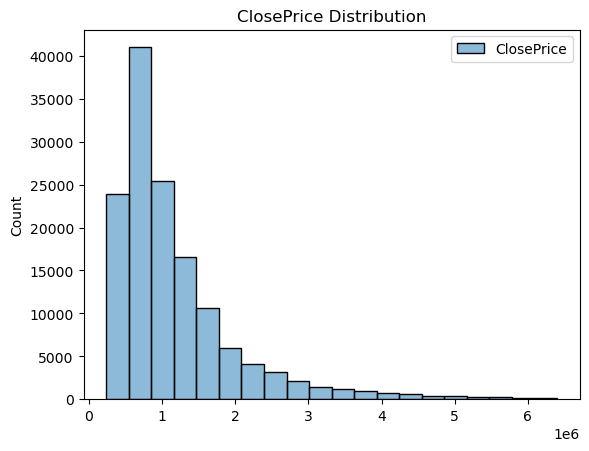

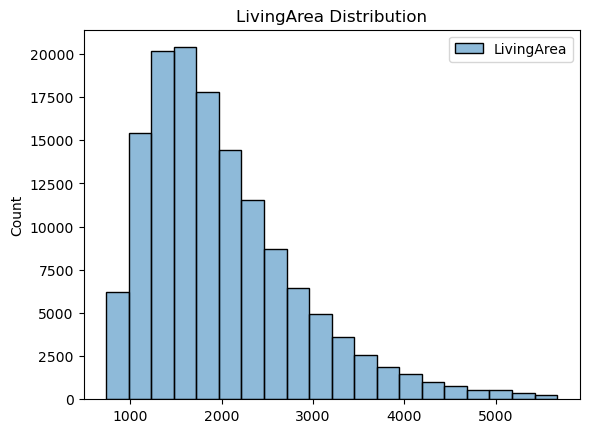

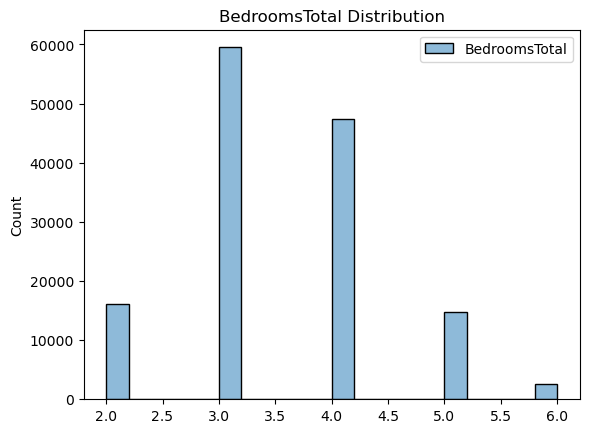

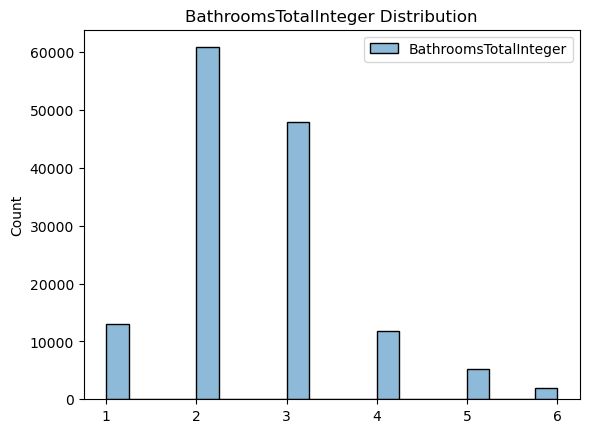

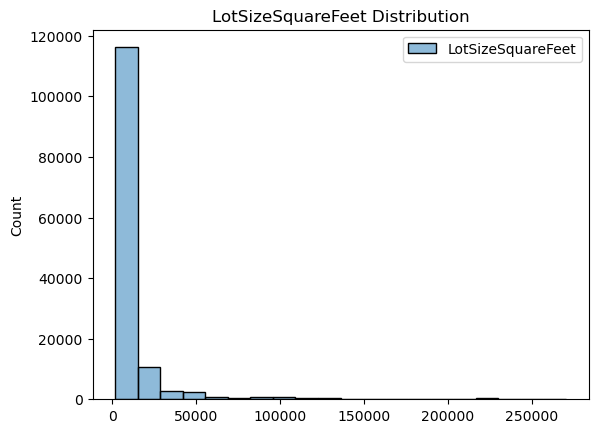

In [13]:
#Plot relevant columns

columns = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger' , 'LotSizeSquareFeet']
for col in columns:
    create_hist(df, col)
    


As we can see in all the plots, the data seems to be mostly right skewed meaning there are a good amount of large outliers. 